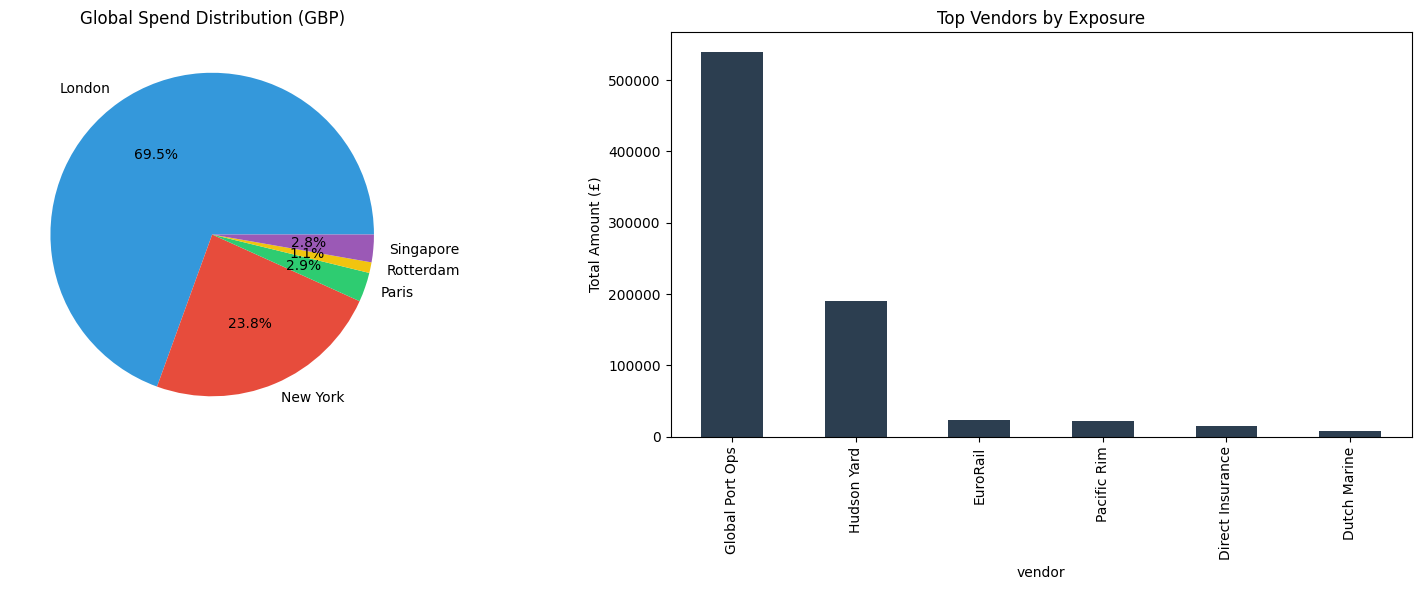

INTERNAL AUDIT SUMMARY REPORT

[ALERT] Duplicates Detected:
            vendor invoice_ref  amount_gbp  instances
0  Global Port Ops      GB-882       45000          2
1      Hudson Yard      US-221       95000          2

[CRITICAL] Authorization Violations (>£100k without Director):
Empty DataFrame
Columns: [trans_id, entity, vendor, amount_gbp, approver]
Index: []

[RISK] Pending Liabilities by Region:
     entity  total_pending
0  New York         190000


In [9]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np

# --- PHASE 1: DATA ENGINEERING ---
# Simulating an international ledger with built-in audit risks
data = {
    'trans_id': [7001, 7002, 7003, 7004, 7005, 7006, 7007, 7008, 7009, 7010],
    'entity': ['London', 'Paris', 'New York', 'London', 'Rotterdam', 'Paris', 'London', 'Singapore', 'London', 'New York'],
    'vendor': ['Global Port Ops', 'EuroRail', 'Hudson Yard', 'Global Port Ops', 'Dutch Marine', 'EuroRail', 'Global Port Ops', 'Pacific Rim', 'Direct Insurance', 'Hudson Yard'],
    'invoice_ref': ['GB-882', 'FR-101', 'US-221', 'GB-882', 'NL-554', 'FR-909', 'GB-441', 'SG-112', 'GB-INS-01', 'US-221'],
    'amount_gbp': [45000, 12000, 95000, 45000, 8500, 11500, 450000, 22000, 15000, 95000],
    'status': ['Paid', 'Paid', 'Pending', 'Paid', 'Paid', 'Paid', 'Paid', 'Paid', 'Paid', 'Pending'],
    'approver': ['Manager_A', 'Manager_B', 'Manager_C', 'Manager_A', 'Manager_B', 'Manager_B', 'Director_X', 'Manager_C', 'System_Auto', 'Manager_C']
}

df = pd.DataFrame(data)
conn = sqlite3.connect('nexus_audit.db')
df.to_sql('ledger', conn, index=False, if_exists='replace')

# --- PHASE 2: FORENSIC SQL QUERIES ---

# 1. Duplicate Payment Detection (Same Vendor, Same Amount, Same Ref)
duplicate_query = """
SELECT vendor, invoice_ref, amount_gbp, COUNT(*) as instances
FROM ledger
GROUP BY vendor, invoice_ref, amount_gbp
HAVING instances > 1;
"""

# 2. Authorization Threshold Check
# London HQ has a limit of £100,000 for Managers. Anything above needs Director approval.
threshold_query = """
SELECT trans_id, entity, vendor, amount_gbp, approver
FROM ledger
WHERE amount_gbp > 100000 AND approver NOT LIKE 'Director%';
"""

# 3. High-Value Pending Liabilities (Liquidity Risk)
liquidity_query = """
SELECT entity, SUM(amount_gbp) as total_pending
FROM ledger
WHERE status = 'Pending'
GROUP BY entity;
"""

# Execute Queries
dupes = pd.read_sql_query(duplicate_query, conn)
threshold_violations = pd.read_sql_query(threshold_query, conn)
liquidity = pd.read_sql_query(liquidity_query, conn)

# --- PHASE 3: EXECUTIVE VISUALIZATION ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Spend by Entity
entity_spend = df.groupby('entity')['amount_gbp'].sum()
entity_spend.plot(kind='pie', autopct='%1.1f%%', ax=ax1, colors=['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#9b59b6'])
ax1.set_title('Global Spend Distribution (GBP)')
ax1.set_ylabel('')

# Chart 2: Vendor Concentration Risk
vendor_spend = df.groupby('vendor')['amount_gbp'].sum().sort_values(ascending=False)
vendor_spend.plot(kind='bar', ax=ax2, color='#2c3e50')
ax2.set_title('Top Vendors by Exposure')
ax2.set_ylabel('Total Amount (£)')

plt.tight_layout()
plt.show()

# --- PHASE 4: AUDIT SUMMARY REPORT ---
print("="*50)
print("INTERNAL AUDIT SUMMARY REPORT")
print("="*50)
print(f"\n[ALERT] Duplicates Detected:\n{dupes}")
print(f"\n[CRITICAL] Authorization Violations (>£100k without Director):\n{threshold_violations}")
print(f"\n[RISK] Pending Liabilities by Region:\n{liquidity}")

In [10]:
# --- PHASE 2: CURRENCY CONVERSION & RISK SCORING ---

# 1. Define Exchange Rates (Targeting GBP for your London HQ context)
# In a real-world scenario, you would use an API, but for this audit, we use fixed rates.
exchange_rates = {
    'GBP': 1.0,
    'EUR': 0.85,  # 1 EUR = 0.85 GBP
    'USD': 0.78,  # 1 USD = 0.78 GBP
    'SGD': 0.58   # 1 SGD = 0.58 GBP
}

# 2. Add Currency information to our dataframe
# (Let's assume different entities billed in their local currency)
df['currency'] = df['entity'].map({'London': 'GBP', 'Paris': 'EUR', 'New York': 'USD', 'Rotterdam': 'EUR', 'Singapore': 'SGD'})

# 3. Create a 'Normalized_Amount' column
df['amount_normalized_gbp'] = df.apply(lambda x: x['amount_gbp'] * exchange_rates[x['currency']], axis=1)

# 4. Create a 'Risk Score' (0 to 100)
# High Risk if: Amount is high AND Approver is not a Director
df['risk_score'] = np.where(
    (df['amount_normalized_gbp'] > 50000) & (df['approver'] != 'Director_X'),
    85, # High risk
    15  # Low risk
)

# Update the SQL database with normalized data
df.to_sql('ledger', conn, index=False, if_exists='replace')

print("Currency Normalization Complete. Risk Scoring applied.")
print(df[['entity', 'amount_gbp', 'currency', 'amount_normalized_gbp', 'risk_score']].head())

Currency Normalization Complete. Risk Scoring applied.
      entity  amount_gbp currency  amount_normalized_gbp  risk_score
0     London       45000      GBP                45000.0          15
1      Paris       12000      EUR                10200.0          15
2   New York       95000      USD                74100.0          85
3     London       45000      GBP                45000.0          15
4  Rotterdam        8500      EUR                 7225.0          15


In [11]:
# Query to find vendors who submitted multiple invoices that, when combined,
# exceed the £100,000 threshold within the same entity.

split_bill_query = """
SELECT vendor, entity, SUM(amount_normalized_gbp) as total_normalized, COUNT(*) as invoice_count
FROM ledger
GROUP BY vendor, entity
HAVING total_normalized > 100000 AND invoice_count > 1;
"""

split_bills = pd.read_sql_query(split_bill_query, conn)
print("AUDIT FINDING: Potential Split-Billing (Threshold Circumvention):")
print(split_bills)

AUDIT FINDING: Potential Split-Billing (Threshold Circumvention):
            vendor    entity  total_normalized  invoice_count
0  Global Port Ops    London          540000.0              3
1      Hudson Yard  New York          148200.0              2


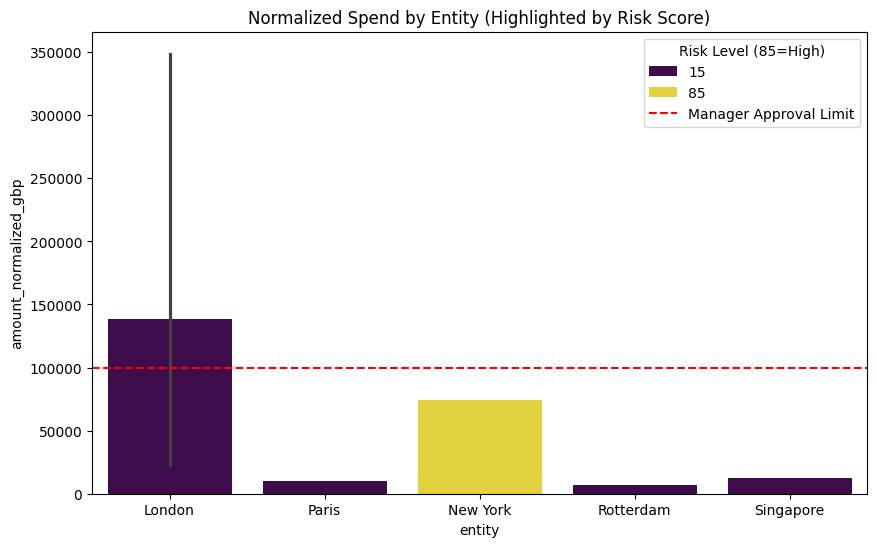

In [12]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='entity', y='amount_normalized_gbp', hue='risk_score', palette='viridis')
plt.axhline(y=100000, color='red', linestyle='--', label='Manager Approval Limit')
plt.title('Normalized Spend by Entity (Highlighted by Risk Score)')
plt.legend(title='Risk Level (85=High)')
plt.show()

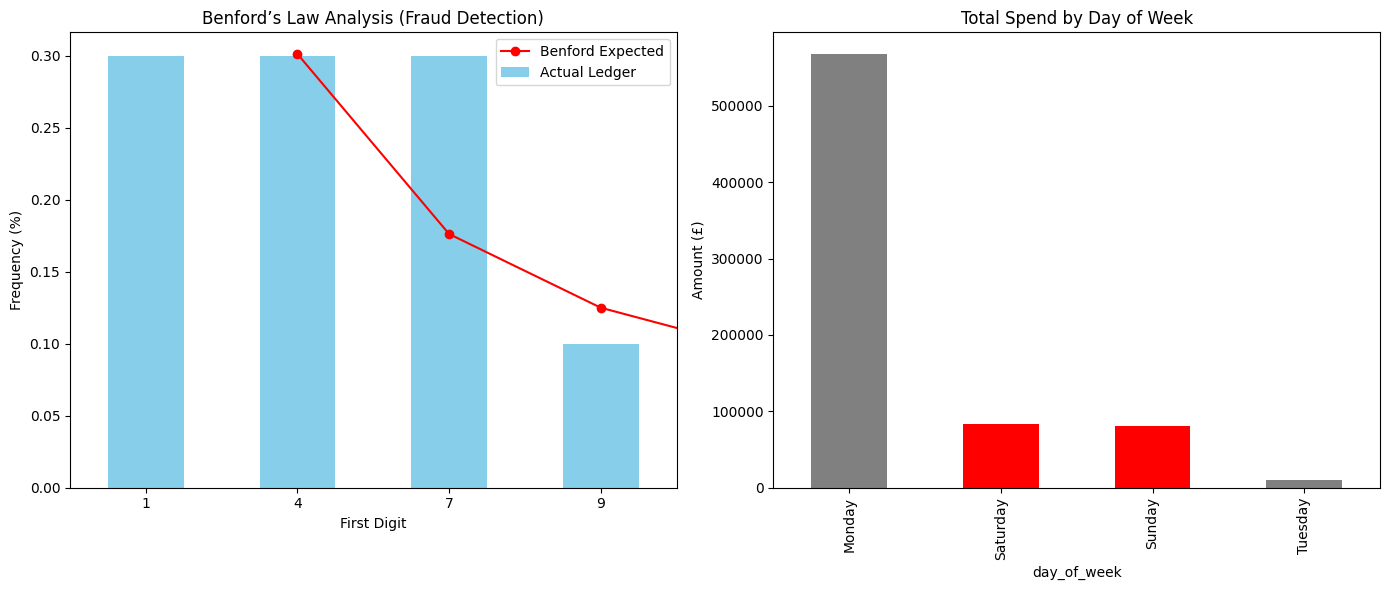

AUDIT NOTE: Detected 4 transactions processed on weekends.


In [13]:
import math

# 1. Benford's Law Analysis: Checking for "Artificial" numbers
def get_first_digit(number):
    if number == 0: return None
    return int(str(abs(number))[0])

# Apply to our normalized amounts
df['first_digit'] = df['amount_normalized_gbp'].apply(get_first_digit)

# Calculate the distribution of first digits in your data
actual_dist = df['first_digit'].value_counts(normalize=True).sort_index()

# Standard Benford's Law Distribution
benford_dist = pd.Series({d: math.log10(1 + 1/d) for d in range(1, 10)})

# 2. Time-Series Analysis: Checking for "Weekend" Transactions
# Fraud often happens on weekends when managers aren't watching.
df['date'] = pd.to_datetime(['2026-01-05', '2026-01-06', '2026-01-10', '2026-01-05', '2026-01-11', '2026-01-10', '2026-01-05', '2026-01-12', '2026-01-05', '2026-01-11'])
df['day_of_week'] = df['date'].dt.day_name()
weekend_issues = df[df['day_of_week'].isin(['Saturday', 'Sunday'])]

# 3. Visualization: The Forensic Report
plt.figure(figsize=(14, 6))

# Plotting Benford's Law Comparison
plt.subplot(1, 2, 1)
actual_dist.plot(kind='bar', color='skyblue', label='Actual Ledger')
benford_dist.plot(kind='line', marker='o', color='red', label='Benford Expected')
plt.title('Benford’s Law Analysis (Fraud Detection)')
plt.xlabel('First Digit')
plt.ylabel('Frequency (%)')
plt.legend()

# Plotting Weekend Spends
plt.subplot(1, 2, 2)
weekend_spend = df.groupby('day_of_week')['amount_normalized_gbp'].sum()
weekend_spend.plot(kind='bar', color=['red' if x in ['Saturday', 'Sunday'] else 'gray' for x in weekend_spend.index])
plt.title('Total Spend by Day of Week')
plt.ylabel('Amount (£)')

plt.tight_layout()
plt.show()

print(f"AUDIT NOTE: Detected {len(weekend_issues)} transactions processed on weekends.")